# Visualizando a atenção em Transformers
Minicurso de Introdução a LLMs: como um modelo decide para onde "olhar" em uma frase.

Roteiro: tokenização, visualização da atenção (BERT), a conta por trás de uma cabeça, padrões por camada, português (BERTimbau) e atenção causal em um LLM gerador (GPT-2).

## 0. Ambiente

In [ ]:
%pip install -q bertviz


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /tmp/claude-1000/-home-joaobezerra/0ee143c0-5c8e-4e42-b839-c7e9bde3355c/scratchpad/venv/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformers
from IPython.display import display
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, utils
from bertviz import head_view, model_view

utils.logging.set_verbosity_error()
torch.set_grad_enabled(False)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"transformers {transformers.__version__} | torch {torch.__version__}")

/tmp/claude-1000/-home-joaobezerra/0ee143c0-5c8e-4e42-b839-c7e9bde3355c/scratchpad/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers 5.17.0 | torch 2.14.0+cpu


In [ ]:
def carregar(nome, classe=AutoModel):
    # eager: a implementação padrão (SDPA) não devolve os pesos de atenção
    tok = AutoTokenizer.from_pretrained(nome)
    mod = classe.from_pretrained(nome, attn_implementation="eager").eval()
    return tok, mod


def atencao(tok, mod, texto):
    enc = tok(texto, return_tensors="pt")
    out = mod(**enc, output_attentions=True)
    tokens = [t.replace("Ġ", "") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return out.attentions, tokens


def posicoes(tok, texto, palavra):
    # índices dos tokens (subpalavras) que compõem a palavra
    m = re.search(rf"\b{re.escape(palavra)}\b", texto)
    offsets = tok(texto, return_offsets_mapping=True)["offset_mapping"]
    return [i for i, (a, b) in enumerate(offsets) if b > a and a < m.end() and b > m.start()]


def peso(att, tok, texto, origem, destino):
    # atenção de `origem` para `destino`, por camada e cabeça: matriz (camadas, cabeças)
    A = torch.stack(att)[:, 0]
    i, j = posicoes(tok, texto, origem), posicoes(tok, texto, destino)
    return A[:, :, i][:, :, :, j].sum(-1).mean(-1).numpy()

## 1. Tokenização: o que o modelo realmente lê

In [ ]:
tok_bert, bert = carregar("google-bert/bert-base-uncased")

for frase in ["The animal didn't cross the street because it was too tired.",
              "Tokenization handles unbelievably uncommon words."]:
    enc = tok_bert(frase)
    display(pd.DataFrame({"token": tok_bert.convert_ids_to_tokens(enc["input_ids"]),
                          "id": enc["input_ids"]}).T)

cfg = bert.config
print(f"vocabulário: {tok_bert.vocab_size:,} tokens | {cfg.num_hidden_layers} camadas x "
      f"{cfg.num_attention_heads} cabeças = {cfg.num_hidden_layers * cfg.num_attention_heads} mapas de atenção")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9339.03it/s]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
token,[CLS],the,animal,didn,',t,cross,the,street,because,it,was,too,tired,.,[SEP]
id,101,1996,4111,2134,1005,1056,2892,1996,2395,2138,2009,2001,2205,5458,1012,102


,0,1,2,3,4,5,6,7,8,9,10,11,12
token,[CLS],token,##ization,handles,un,##bel,##ie,##va,##bly,uncommon,words,.,[SEP]
id,101,19204,3989,16024,4895,8671,2666,3567,6321,13191,2616,1012,102


vocabulário: 30,522 tokens | 12 camadas x 12 cabeças = 144 mapas de atenção


## 2. Para onde "it" olha?
Duas frases que diferem em uma palavra. Em *tired*, "it" é o animal; em *wide*, é a rua.

In [ ]:
frase_a = "The animal didn't cross the street because it was too tired."
frase_b = "The animal didn't cross the street because it was too wide."

att_a, tok_a = atencao(tok_bert, bert, frase_a)
att_b, tok_b = atencao(tok_bert, bert, frase_b)
print(f"{len(att_a)} camadas, cada uma com shape {tuple(att_a[0].shape)} = (batch, cabeças, tokens, tokens)")

head_view(att_a, tok_a)

12 camadas, cada uma com shape (1, 12, 16, 16) = (batch, cabeças, tokens, tokens)


<IPython.core.display.Javascript object>

In [ ]:
head_view(att_b, tok_b)

<IPython.core.display.Javascript object>

### Quais cabeças mudam de opinião com o contexto?

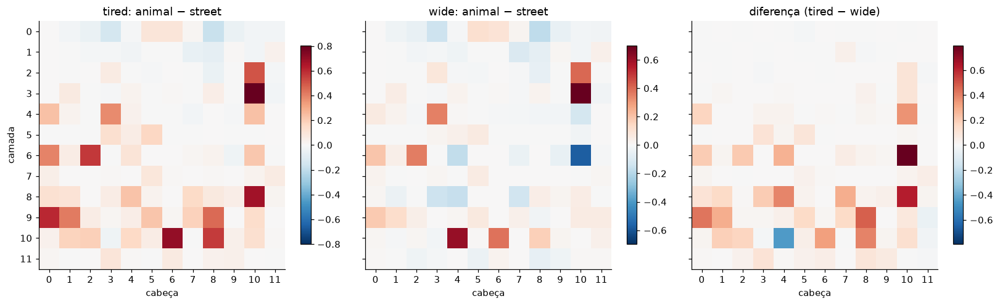

,camada,cabeça,pref_tired,pref_wide,delta
82,6,10,0.217,-0.578,0.795
106,8,10,0.675,0.050,0.625
116,9,8,0.452,-0.022,0.474
124,10,4,0.158,0.610,-0.452
108,9,0,0.606,0.181,0.425


In [ ]:
# preferência > 0: "it" olha mais para "animal" do que para "street"
pref_a = peso(att_a, tok_bert, frase_a, "it", "animal") - peso(att_a, tok_bert, frase_a, "it", "street")
pref_b = peso(att_b, tok_bert, frase_b, "it", "animal") - peso(att_b, tok_bert, frase_b, "it", "street")
delta = pref_a - pref_b

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, (titulo, m) in zip(axes, [("tired: animal − street", pref_a),
                                  ("wide: animal − street", pref_b),
                                  ("diferença (tired − wide)", delta)]):
    lim = np.abs(m).max()
    im = ax.imshow(m, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set(title=titulo, xlabel="cabeça", xticks=range(12))
    fig.colorbar(im, ax=ax, shrink=0.8)
axes[0].set(ylabel="camada", yticks=range(12))
plt.tight_layout(); plt.show()

top = pd.DataFrame([(l, h, pref_a[l, h], pref_b[l, h], delta[l, h])
                    for l in range(12) for h in range(12)],
                   columns=["camada", "cabeça", "pref_tired", "pref_wide", "delta"])
top = top.reindex(top["delta"].abs().sort_values(ascending=False).index).head(5)
display(top.round(3))

In [ ]:
# cabeça mais sensível ao contexto, lado a lado nas duas frases
l, h = map(int, top.iloc[0][["camada", "cabeça"]])
print(f"camada {l}, cabeça {h}")
head_view(att_a, tok_a, layer=l, heads=[h])
head_view(att_b, tok_b, layer=l, heads=[h])

camada 6, cabeça 10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. A conta por trás de uma cabeça
$\text{Atenção}(Q, K) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)$, com $Q = XW_Q$ e $K = XW_K$.
Recalculamos à mão e comparamos com o que o modelo devolveu.

Q: (16, 64) | K: (16, 64) | scores: (16, 16)
igual ao modelo? True


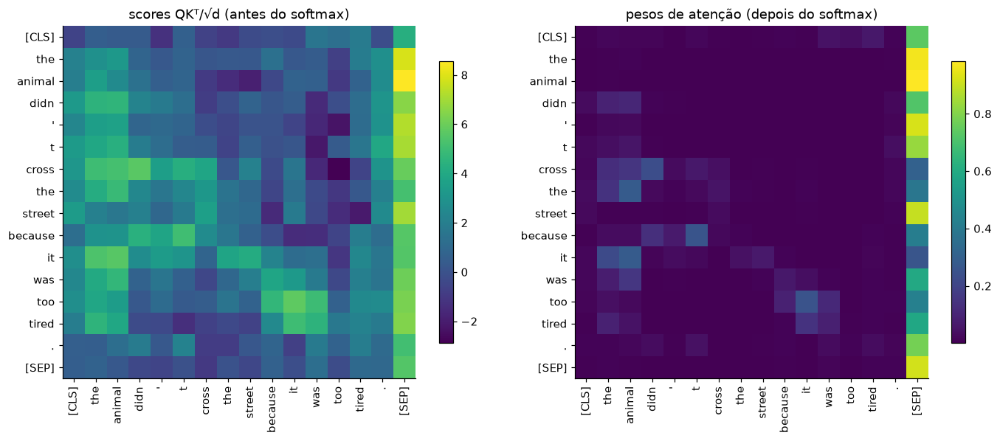

In [ ]:
enc = tok_bert(frase_a, return_tensors="pt")
out = bert(**enc, output_attentions=True, output_hidden_states=True)

n_heads = cfg.num_attention_heads
d_k = cfg.hidden_size // n_heads
X = out.hidden_states[l][0]                       # entrada da camada l: (tokens, 768)
sa = bert.encoder.layer[l].attention.self

Q = sa.query(X).view(-1, n_heads, d_k)[:, h]      # (tokens, 64)
K = sa.key(X).view(-1, n_heads, d_k)[:, h]
scores = Q @ K.T / d_k ** 0.5
pesos = scores.softmax(dim=-1)

print("Q:", tuple(Q.shape), "| K:", tuple(K.shape), "| scores:", tuple(scores.shape))
print("igual ao modelo?", torch.allclose(pesos, out.attentions[l][0, h], atol=1e-5))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, m, titulo in [(axes[0], scores, "scores QKᵀ/√d (antes do softmax)"),
                      (axes[1], pesos, "pesos de atenção (depois do softmax)")]:
    im = ax.imshow(m.numpy(), cmap="viridis")
    ax.set(title=titulo, xticks=range(len(tok_a)), yticks=range(len(tok_a)))
    ax.set_xticklabels(tok_a, rotation=90); ax.set_yticklabels(tok_a)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 4. Visão geral: todas as camadas e cabeças

In [ ]:
model_view(att_a, tok_a)

<IPython.core.display.Javascript object>

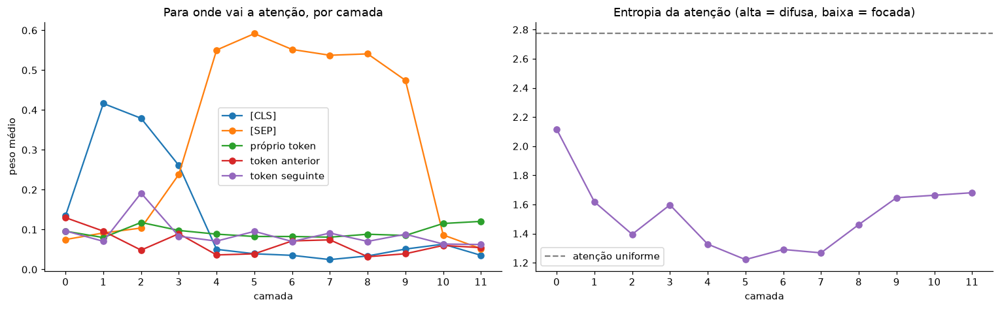

In [ ]:
A = torch.stack(att_a)[:, 0]                      # (camadas, cabeças, tokens, tokens)
media = lambda x: x.mean(dim=(1, 2)).numpy()      # média por camada

padroes = pd.DataFrame({
    "[CLS]": media(A[..., 0]),
    "[SEP]": media(A[..., -1]),
    "próprio token": media(A.diagonal(dim1=-2, dim2=-1)),
    "token anterior": media(A.diagonal(offset=-1, dim1=-2, dim2=-1)),
    "token seguinte": media(A.diagonal(offset=1, dim1=-2, dim2=-1)),
})
entropia = (-(A * A.clamp_min(1e-12).log()).sum(-1)).mean(dim=(1, 2)).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
padroes.plot(ax=axes[0], marker="o")
axes[0].set(title="Para onde vai a atenção, por camada", xlabel="camada", ylabel="peso médio", xticks=range(12))
axes[1].plot(entropia, marker="o", color="tab:purple")
axes[1].axhline(np.log(len(tok_a)), ls="--", color="gray", label="atenção uniforme")
axes[1].set(title="Entropia da atenção (alta = difusa, baixa = focada)", xlabel="camada", xticks=range(12))
axes[1].legend(); plt.tight_layout(); plt.show()

## 5. Em português: BERTimbau
Esquema de Winograd clássico. Aqui o gênero de "ele"/"ela" já dá uma pista gramatical que o inglês não dá.

In [ ]:
tok_pt, bert_pt = carregar("neuralmind/bert-base-portuguese-cased")

frase_pt_a = "O troféu não coube na mala porque ele era grande demais."
frase_pt_b = "O troféu não coube na mala porque ela era pequena demais."
att_pt_a, tok_pt_a = atencao(tok_pt, bert_pt, frase_pt_a)
att_pt_b, tok_pt_b = atencao(tok_pt, bert_pt, frase_pt_b)
print(tok_pt_a)

head_view(att_pt_a, tok_pt_a)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18465.66it/s]

['[CLS]', 'O', 'troféu', 'não', 'co', '##ube', 'na', 'mala', 'porque', 'ele', 'era', 'grande', 'demais', '.', '[SEP]']


<IPython.core.display.Javascript object>

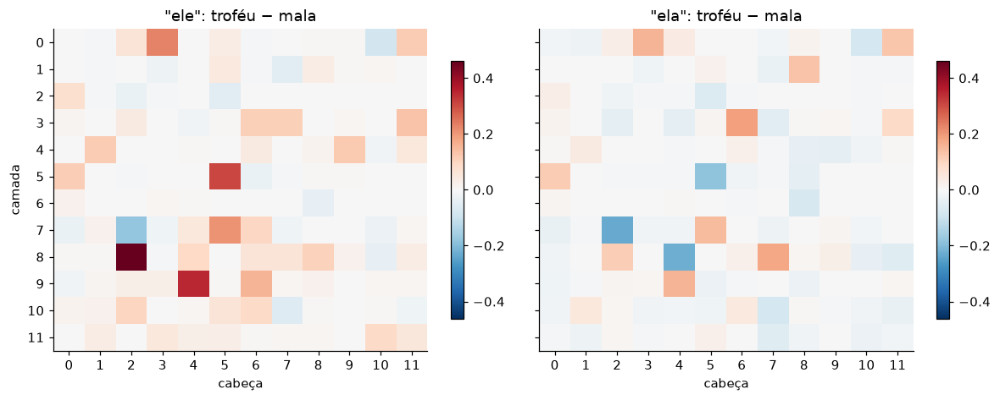

In [ ]:
# preferência > 0: o pronome olha mais para "troféu" do que para "mala"
prefs = {pron: peso(att, tok_pt, frase, pron, "troféu") - peso(att, tok_pt, frase, pron, "mala")
         for frase, att, pron in [(frase_pt_a, att_pt_a, "ele"), (frase_pt_b, att_pt_b, "ela")]}
lim = max(np.abs(m).max() for m in prefs.values())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, (pron, m) in zip(axes, prefs.items()):
    im = ax.imshow(m, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set(title=f'"{pron}": troféu − mala', xlabel="cabeça", xticks=range(12))
    fig.colorbar(im, ax=ax, shrink=0.8)
axes[0].set(ylabel="camada", yticks=range(12))
plt.tight_layout(); plt.show()

## 6. LLMs geradores: atenção causal (GPT-2)
Um decoder só pode olhar para trás, porque o próximo token ainda não existe.

In [ ]:
tok_gpt, gpt = carregar("openai-community/gpt2", AutoModelForCausalLM)

prompt = "The animal didn't cross the street because it was too"
att_g, tok_g = atencao(tok_gpt, gpt, prompt)
head_view(att_g, tok_g)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8353.61it/s]

<IPython.core.display.Javascript object>

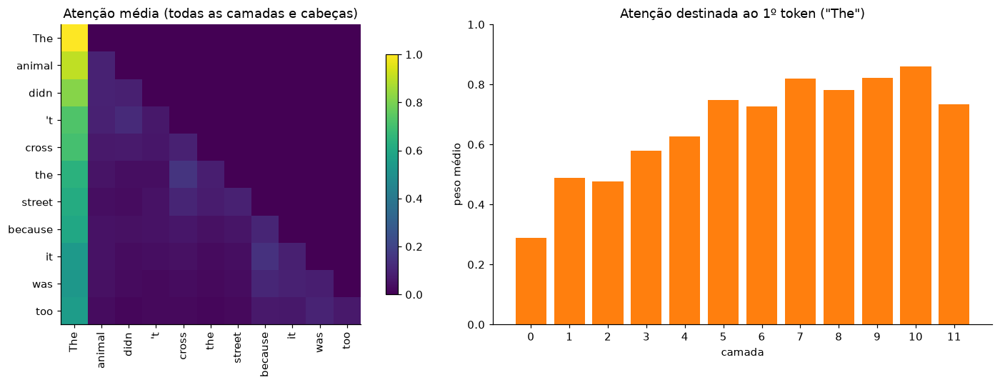

In [ ]:
G = torch.stack(att_g)[:, 0]                      # (camadas, cabeças, tokens, tokens)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(G.mean(dim=(0, 1)).numpy(), cmap="viridis")
axes[0].set(title="Atenção média (todas as camadas e cabeças)",
            xticks=range(len(tok_g)), yticks=range(len(tok_g)))
axes[0].set_xticklabels(tok_g, rotation=90); axes[0].set_yticklabels(tok_g)
fig.colorbar(im, ax=axes[0], shrink=0.8)

# fração da atenção que cai no primeiro token ("attention sink"), ignorando a 1ª linha
sink = G[:, :, 1:, 0].mean(dim=(1, 2)).numpy()
axes[1].bar(range(len(sink)), sink, color="tab:orange")
axes[1].set(title=f'Atenção destinada ao 1º token ("{tok_g[0]}")', xlabel="camada", ylabel="peso médio",
            xticks=range(len(sink)), ylim=(0, 1))
plt.tight_layout(); plt.show()

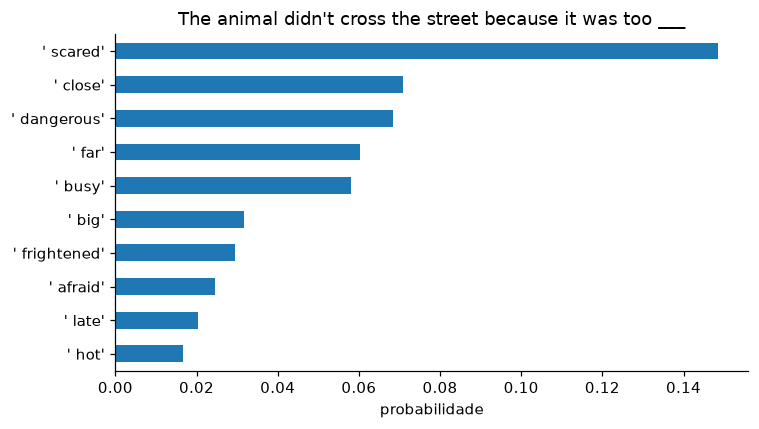

In [ ]:
# do mapa de atenção à previsão: os 10 próximos tokens mais prováveis
logits = gpt(**tok_gpt(prompt, return_tensors="pt")).logits[0, -1]
probs = logits.softmax(-1)
top_p, top_i = probs.topk(10)
prev = pd.Series(top_p.numpy(), index=[repr(tok_gpt.decode(i)) for i in top_i]).iloc[::-1]

ax = prev.plot.barh(figsize=(7, 4), color="tab:blue")
ax.set(title=f"{prompt} ___", xlabel="probabilidade")
plt.tight_layout(); plt.show()

## Achados
- **Tokens não são palavras.** "didn't" vira 3 tokens e "unbelievably" vira 5 subpalavras (`un ##bel ##ie ##va ##bly`). O modelo nunca vê a palavra inteira, só pedaços de um vocabulário fixo de 30.522 tokens.
- **Algumas cabeças resolvem o "it" pelo contexto.** A camada 6, cabeça 10 inverte de lado: com *tired*, "it" olha mais para "animal" (+0,22); com *wide*, olha para "street" (−0,58). Várias cabeças das camadas 8 a 10 também mudam, mas a maioria das 144 é indiferente: a resolução é distribuída e ocupa poucas cabeças.
- **Atenção é só álgebra.** Recalculamos softmax(QKᵀ/√d) à mão e o resultado bate com o modelo. Não há nada mágico: são projeções lineares, um produto escalar e uma normalização.
- **Cada camada tem uma função.** Nas primeiras camadas, a atenção vai para [CLS] e para vizinhos; nas camadas 4 a 8, mais de 50% do peso cai em [SEP]. Isso funciona como um "no-op": quando a cabeça não tem o que fazer, estaciona a atenção ali. A entropia é mínima no meio da rede, onde a atenção é mais focada.
- **Atenção ≠ explicação.** Pesos altos em [SEP] ou no primeiro token mostram que a atenção nem sempre aponta para o que é semanticamente relevante. É uma pista, não uma prova do raciocínio do modelo.
- **Em português, o gênero ajuda, mas não simplifica.** "ele" tende a olhar para "troféu" (camada 8, cabeça 2); com "ela", o sinal é mais fraco e se divide entre cabeças que preferem "mala" e cabeças que preferem "troféu".
- **LLMs geradores só olham para trás.** A máscara causal do GPT-2 deixa a matriz triangular. De 30% a 86% da atenção, conforme a camada, vai para o primeiro token (*attention sink*), fenômeno explorado em técnicas de contexto longo.
- **Da atenção à previsão.** Para "...because it was too ___", o GPT-2 prefere *scared* (15%) e depois *close*, *dangerous* e *far*: continuações ligadas tanto ao animal quanto à rua.